In [11]:
import torch 

inputs = torch.tensor(
    [[0.43, 0.15, 0.89], # Your (x^1)
    [0.55, 0.87, 0.66], # journey (x^2)
    [0.57, 0.85, 0.64], # starts (x^3)
    [0.22, 0.58, 0.33], # with (x^4)
    [0.77, 0.25, 0.10], # one (x^5)
    [0.05, 0.80, 0.55]] # step (x^6)
)

In [12]:
query = inputs[1]
print(query)
atten_scores_2 = torch.empty(inputs.shape[0])
print(atten_scores_2)
for i, xi in enumerate(inputs):
    atten_scores_2[i] = torch.dot(query, xi)

print(atten_scores_2)

atten_scores_2_normalize = atten_scores_2/atten_scores_2.sum()
print(atten_scores_2_normalize)
print(atten_scores_2_normalize.sum())


# softmax 
def softmax_naive(x): 
    return torch.exp(x) / torch.exp(x).sum(dim=0)

atten_score2_softmax = softmax_naive(atten_scores_2)
print(atten_score2_softmax)
print(atten_score2_softmax.sum())

tensor([0.5500, 0.8700, 0.6600])
tensor([1.9756e-01, 0.0000e+00, 1.9648e-01, 0.0000e+00, 1.1210e-43, 0.0000e+00])
tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])
tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
tensor(1.0000)
tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
tensor(1.)


In [13]:
# test attention score for x2 
atten_score_2 = torch.empty(inputs.shape[0])
x_2 = inputs[1]
for i, xi in enumerate(inputs):
    atten_score_2[i] = torch.dot(xi, x_2)
print("atten weight", atten_score_2)

# softmax 
atten_score_2_softmax = softmax_naive(atten_score_2)
print("after naive softmax", atten_score_2_softmax)

# weighted sum 
context_vector = torch.zeros(inputs.shape[1])
for i, xi in enumerate(inputs):
    context_vector += atten_score_2_softmax[i] * xi
    
print("context vec 2", context_vector)
    
    
print("\n\n")

# use matmul 
atten_weight_matrix = torch.matmul(inputs, inputs.T)
print("atten weight matmul", atten_weight_matrix[1])
atten_weight_matrix_softmax = torch.softmax(atten_weight_matrix, dim=1) # (num vectors, weight softmax vector)
print(atten_weight_matrix_softmax[1])
# print(atten_weight_matrix_softmax)
# context vector -> weighted sum of all vector with softmax 
context_vector = torch.matmul(atten_weight_matrix_softmax, inputs) #(num_vectors, weight softmax num_vector) (num_vector, vector dim)
print(context_vector[1])




atten weight tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])
after naive softmax tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
context vec 2 tensor([0.4419, 0.6515, 0.5683])



atten weight matmul tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])
tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
tensor([0.4419, 0.6515, 0.5683])


# Self-Attention 
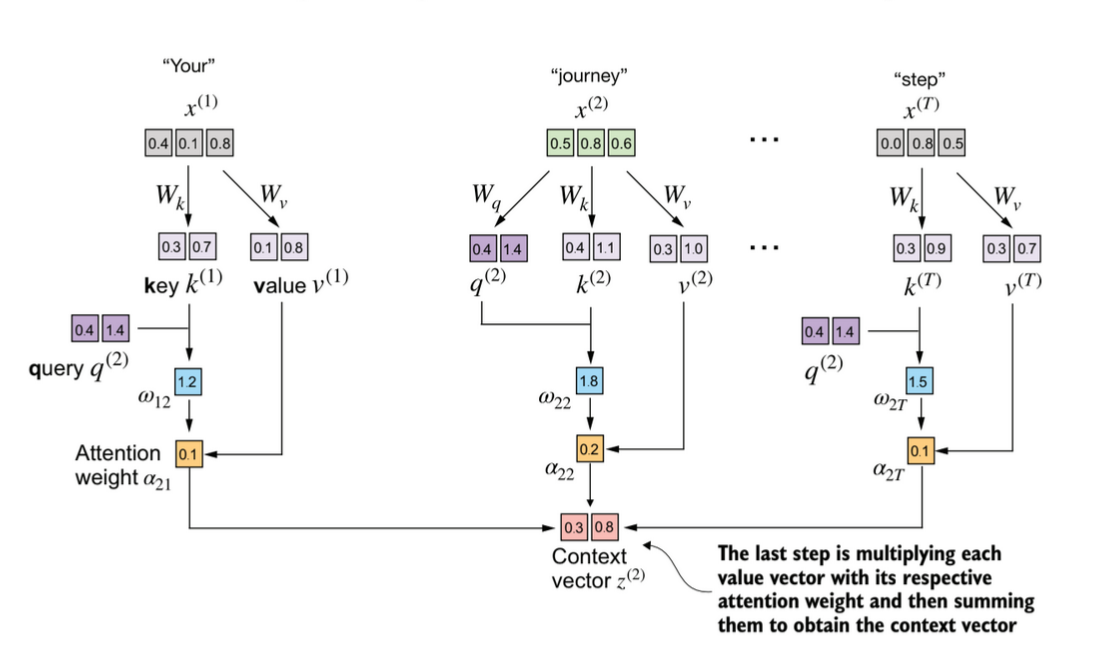

In [14]:
import torch.nn as nn
class SelfAttentionv1(nn.Module): 
    def __init__(self, in_dim, out_dim):
        super().__init__()
        # GPT-like: in_dim = embed_dim of the input and in_dim = out_dim
        self.query_weight = torch.nn.Parameter(torch.randn((in_dim, out_dim)))
        self.key_weight = torch.nn.Parameter(torch.randn((in_dim, out_dim)))
        self.value_weight = torch.nn.Parameter(torch.randn((in_dim, out_dim)))

    def forward(self, x): 
        # x (num_vectors, embed_dim)
        query = torch.matmul(x, self.query_weight) # (num_vectors, out_dim)
        key = torch.matmul(x, self.key_weight) # same 
        value = torch.matmul(x, self.value_weight) # same 

        attention_scores = torch.matmul(query, key.T) # (num_vectors, attention_scores of num_vectors), or row is query num, column is key num (the value hold is attention scores)
        # normalize attention_scores 
        attention_scores = attention_scores * (key.shape[-1]**(-0.5))
        
        attention_weight = torch.softmax(attention_scores, dim=-1) # softmax on attention score dim (key num, column)
        # (num_vectors, attention weight of num_vector)

        # weighted sum 
        # value is real value of the key, key is just like the index 
        context = torch.matmul(attention_weight, value)

        return context 
    

# test 
torch.manual_seed(123)
sa_v1 = SelfAttentionv1(3, 2)
print(sa_v1(inputs))
        





        

tensor([[0.2845, 0.4071],
        [0.2854, 0.4081],
        [0.2854, 0.4075],
        [0.2864, 0.3974],
        [0.2863, 0.3910],
        [0.2860, 0.4039]], grad_fn=<MmBackward0>)


In [15]:
import torch.nn as nn
class SelfAttentionv2(nn.Module): 
    def __init__(self, in_dim, out_dim, qkv_bias=False):
        super().__init__()
        # GPT-like: in_dim = embed_dim of the input and in_dim = out_dim
        self.query_proj = nn.Linear(in_dim, out_dim, bias=qkv_bias)
        self.key_proj = nn.Linear(in_dim, out_dim, bias=qkv_bias)
        self.value_proj = nn.Linear(in_dim, out_dim, bias=qkv_bias)

    def forward(self, x): 
        # x (num_vectors, embed_dim)
        query = self.query_proj(x)
        key = self.key_proj(x)
        value = self.value_proj(x)

        attention_scores = torch.matmul(query, key.T) # (num_vectors, attention_scores of num_vectors), or row is query num, column is key num (the value hold is attention scores)
        # normalize attention_scores 
        attention_scores = attention_scores * (key.shape[-1]**(-0.5))
        
        attention_weight = torch.softmax(attention_scores, dim=-1) # softmax on attention score dim (key num, column)
        # (num_vectors, attention weight of num_vector)

        # weighted sum 
        # value is real value of the key, key is just like the index 
        context = torch.matmul(attention_weight, value)

        return context 

torch.manual_seed(123)
sa_v1 = SelfAttentionv2(3, 2)
print(sa_v1(inputs))




tensor([[-0.5337, -0.1051],
        [-0.5323, -0.1080],
        [-0.5323, -0.1079],
        [-0.5297, -0.1076],
        [-0.5311, -0.1066],
        [-0.5299, -0.1081]], grad_fn=<MmBackward0>)


# Exercise:
- Copy weight of SAv1 to SAv2 


In [16]:
sa_v1 = SelfAttentionv1(3, 2)
sa_v2 = SelfAttentionv2(3, 2)

y1 = sa_v1(inputs)
y2 = sa_v2(inputs)

print("y1: ", y1)
print("y2: ", y2)


# copy weight 
with torch.no_grad():
    sa_v2.query_proj.weight.copy_(sa_v1.query_weight.T)
    sa_v2.key_proj.weight.copy_(sa_v1.key_weight.T)
    sa_v2.value_proj.weight.copy_(sa_v1.value_weight.T)

# 
y2 = sa_v2(inputs)
print("y2 after copy weight", y2)

y1:  tensor([[-2.1641,  0.7651],
        [-2.1626,  0.8028],
        [-2.1609,  0.8035],
        [-2.1297,  0.7334],
        [-2.1162,  0.7797],
        [-2.1485,  0.7323]], grad_fn=<MmBackward0>)
y2:  tensor([[-0.3974,  0.5980],
        [-0.4012,  0.5952],
        [-0.4010,  0.5952],
        [-0.3975,  0.5969],
        [-0.3950,  0.5957],
        [-0.3997,  0.5971]], grad_fn=<MmBackward0>)
y2 after copy weight tensor([[-2.1641,  0.7651],
        [-2.1626,  0.8028],
        [-2.1609,  0.8035],
        [-2.1297,  0.7334],
        [-2.1162,  0.7797],
        [-2.1485,  0.7323]], grad_fn=<MmBackward0>)


# Causal Attention



In [17]:
import torch.nn as nn
class CausalAttention(nn.Module): 
    def __init__(self, in_dim, out_dim, qkv_bias=False):
        super().__init__()
        # GPT-like: in_dim = embed_dim of the input and in_dim = out_dim
        self.query_proj = nn.Linear(in_dim, out_dim, bias=qkv_bias)
        self.key_proj = nn.Linear(in_dim, out_dim, bias=qkv_bias)
        self.value_proj = nn.Linear(in_dim, out_dim, bias=qkv_bias)
        self.dropout = nn.Dropout(p=0.5, inplace=False)

    def forward(self, x): 
        # x (num_vectors, embed_dim)
        query = self.query_proj(x)
        key = self.key_proj(x)
        value = self.value_proj(x)

        attention_scores = torch.matmul(query, key.T) # (num_vectors, attention_scores of num_vectors), or row is query num, column is key num (the value hold is attention scores)
        # normalize attention_scores 
        attention_scores = attention_scores * (key.shape[-1]**(-0.5))
        
        # attention_weight = torch.softmax(attention_scores, dim=-1) # softmax on attention score dim (key num, column)
        # (num_vectors, attention weight of num_vector)

        # create attention mask using triangle lower 
        # attention_mask = torch.tril(attention_weight, diagonal=0) # diagonal = 0 because this is square matrix, and we want it can attend to itself
        # print(attention_mask)
        
        # # normalize again 
        # attention_mask_simple_norm = attention_mask / attention_mask.sum(dim=-1, keepdim=True)  # must keep dim
        # print(attention_mask.sum(dim=-1, keepdim=True))
        # print(attention_mask_simple_norm)
        
        
        # new way to implement masking
        mask = torch.triu(torch.ones_like(attention_scores), diagonal=1)
        print(mask.bool())
        masked = torch.masked_fill(attention_scores, mask.bool(), -torch.inf)
        print(masked)
        
        attention_weight = torch.softmax(masked / key.shape[-1]**-0.5, dim=-1)

        # dropout
        attention_weight_dropout = self.dropout(attention_weight)
        print(attention_weight_dropout)
        print(attention_weight)
        # weighted sum 
        # value is real value of the key, key is just like the index 
        context = torch.matmul(attention_weight_dropout, value)

        return context 

torch.manual_seed(123)
ca_v1 = CausalAttention(3, 2)
print(ca_v1(inputs))

tensor([[False,  True,  True,  True,  True,  True],
        [False, False,  True,  True,  True,  True],
        [False, False, False,  True,  True,  True],
        [False, False, False, False,  True,  True],
        [False, False, False, False, False,  True],
        [False, False, False, False, False, False]])
tensor([[0.2200,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.1170, 0.1840,   -inf,   -inf,   -inf,   -inf],
        [0.1179, 0.1840, 0.1822,   -inf,   -inf,   -inf],
        [0.0361, 0.0764, 0.0752, 0.0455,   -inf,   -inf],
        [0.1000, 0.1326, 0.1317, 0.0698, 0.0793,   -inf],
        [0.0337, 0.0843, 0.0828, 0.0517, 0.0337, 0.0683]],
       grad_fn=<MaskedFillBackward0>)
tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.9527, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.6860, 0.0000, 0.0000, 0.0000],
        [0.4844, 0.0000, 0.5120, 0.0000, 0.0000, 0.0000],
        [0.3983, 0.4170, 0.0000, 0.3816, 0.0000, 0.0000],
        [0

In [18]:
# test dropout
dropout = torch.nn.Dropout(p=0.5,inplace=False) # inplace = false, still keep the original, just copy to new tensor, inplace= true, change the original, easy to break 
# auto * the original with (1/(1-p)) to compensate the drops
test = torch.ones((6,6))
print(dropout(test))


# the different between nn.Dropout and F.dropout is, nn.Dropout auto turn off when model.eval(), F.dropout must pass the self.training parameters to control it 



tensor([[0., 2., 2., 0., 2., 2.],
        [2., 2., 2., 0., 0., 2.],
        [2., 0., 2., 0., 0., 0.],
        [0., 2., 2., 2., 2., 0.],
        [2., 2., 2., 0., 0., 2.],
        [2., 2., 0., 2., 2., 0.]])


In [29]:
import torch.nn as nn
class CausalAttentionv2(nn.Module): 
    def __init__(self, in_dim, out_dim, context_length, dropout=0.5,qkv_bias=False):
        super().__init__()
        # GPT-like: in_dim = embed_dim of the input and in_dim = out_dim
        self.out_dim = out_dim
        self.query_proj = nn.Linear(in_dim, out_dim, bias=qkv_bias)
        self.key_proj = nn.Linear(in_dim, out_dim, bias=qkv_bias)
        self.value_proj = nn.Linear(in_dim, out_dim, bias=qkv_bias)
        self.dropout = nn.Dropout(p=dropout, inplace=False)
        self.register_buffer(
            'mask' , 
            torch.triu(torch.ones((context_length, context_length)), diagonal=1)
        )

    def forward(self, x): 
        # x (batch , num_vectors, embed_dim)
        batches, num_tokens, in_dim = x.shape
        query = self.query_proj(x)
        key = self.key_proj(x)
        value = self.value_proj(x)

        attention_scores = torch.matmul(query, torch.transpose(key, -1, -2)) # (num_vectors, attention_scores of num_vectors), or row is query num, column is key num (the value hold is attention scores)
        # normalize attention_scores 
        d_k = key.shape[-1]
        
        # create mask 
        attention_scores.masked_fill_( # fill in_place 
            self.mask.bool()[:num_tokens][:num_tokens], -torch.inf
        )
        
         
        # weighted sum 
        attention_weight = torch.softmax(attention_scores/(d_k**0.5), dim=-1)
        attention_weight_dropout = self.dropout(attention_weight)
        # value is real value of the key, key is just like the index 
        context = torch.matmul(attention_weight_dropout, value)

        return context 

torch.manual_seed(123)
batch = torch.stack((inputs, inputs))
ca_v1 = CausalAttentionv2(3, 2, 6)
print(ca_v1(batch))

tensor([[[-0.9038,  0.4432],
         [-0.4368,  0.2142],
         [-0.4849, -0.1341],
         [-0.5834,  0.0081],
         [-0.6219, -0.0526],
         [-0.1417, -0.0505]],

        [[ 0.0000,  0.0000],
         [-1.1749,  0.0116],
         [-0.7733,  0.0073],
         [-0.9140, -0.2769],
         [-0.7679, -0.0735],
         [-0.6749, -0.0984]]], grad_fn=<UnsafeViewBackward0>)


# Simple Multi-head Attention

In [38]:
class SimpleMultiHeadAttention(nn.Module): 
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False): 
        super().__init__()
        self.heads = nn.ModuleList([
            CausalAttentionv2(d_in, d_out, context_length, dropout, qkv_bias) 
            for _ in range(num_heads)
        ])

    def forward(self, x): 
        # concat all head 
        # each head has (B, ContextLength, d_in head)
        # we need to concat the d_in head, d_concat = d_in_head * num_heads
        heads = [head(x) for head in self.heads]
        print(heads)
        return torch.concat([head.forward(x) for head in self.heads], dim=-1)

        
# print()
# print(ca_v1(batch))
# print(ca_v1(batch))
simple_MHA = SimpleMultiHeadAttention(3, 2, context_length=6, dropout=0.0, num_heads=2)
print(simple_MHA(batch))

[tensor([[[-0.5048, -0.0654],
         [-0.3583, -0.2596],
         [-0.3145, -0.3119],
         [-0.2558, -0.3036],
         [-0.2320, -0.2448],
         [-0.2112, -0.2801]],

        [[-0.5048, -0.0654],
         [-0.3583, -0.2596],
         [-0.3145, -0.3119],
         [-0.2558, -0.3036],
         [-0.2320, -0.2448],
         [-0.2112, -0.2801]]], grad_fn=<UnsafeViewBackward0>), tensor([[[-0.3746,  0.0184],
         [-0.4482,  0.0512],
         [-0.4721,  0.0653],
         [-0.4222,  0.0546],
         [-0.4048,  0.0914],
         [-0.3883,  0.0644]],

        [[-0.3746,  0.0184],
         [-0.4482,  0.0512],
         [-0.4721,  0.0653],
         [-0.4222,  0.0546],
         [-0.4048,  0.0914],
         [-0.3883,  0.0644]]], grad_fn=<UnsafeViewBackward0>)]
tensor([[[-0.5048, -0.0654, -0.3746,  0.0184],
         [-0.3583, -0.2596, -0.4482,  0.0512],
         [-0.3145, -0.3119, -0.4721,  0.0653],
         [-0.2558, -0.3036, -0.4222,  0.0546],
         [-0.2320, -0.2448, -0.4048,  0.091

1. Thay đổi Hình dạng và Cấu trúc Trục (Reshaping & Permuting)Bản chất của một Tensor trong bộ nhớ máy tính là một mảng 1D liên tục. PyTorch quản lý hình dạng bằng shape và stride (bước nhảy trong bộ nhớ)..view() vs .reshape().view(*shape):Bản chất: Tạo một góc nhìn mới dựa trên cùng một vùng nhớ gốc. Cực kỳ nhanh vì độ phức tạp thời gian là $O(1)$.Điều kiện: Tensor phải liên tục (contiguous) trong bộ nhớ. Nếu bạn vừa hoán vị trục, .view() sẽ báo lỗi..reshape(*shape):Bản chất: Linh hoạt hơn. Nếu dữ liệu liên tục, nó sẽ gọi .view(). Nếu dữ liệu không liên tục (sau khi transpose/permute), nó sẽ tự động copy dữ liệu sang vùng nhớ mới (tương đương với .contiguous().view()).

In [64]:
torch.manual_seed(123)
x = torch.randn((4, 4))
print(x)
x = x.view(4, 2, 2)
print(x)
x = x.transpose(-1, -2)
# x = x.transpose(-1, -2)
x = x.contiguous()
print(x)
x = x.view(4, 4)


print(x)

tensor([[ 0.3374, -0.1778, -0.3035, -0.5880],
        [ 0.3486,  0.6603, -0.2196, -0.3792],
        [ 0.7671, -1.1925,  0.6984, -1.4097],
        [ 0.1794,  1.8951,  0.4954,  0.2692]])
tensor([[[ 0.3374, -0.1778],
         [-0.3035, -0.5880]],

        [[ 0.3486,  0.6603],
         [-0.2196, -0.3792]],

        [[ 0.7671, -1.1925],
         [ 0.6984, -1.4097]],

        [[ 0.1794,  1.8951],
         [ 0.4954,  0.2692]]])
tensor([[[ 0.3374, -0.3035],
         [-0.1778, -0.5880]],

        [[ 0.3486, -0.2196],
         [ 0.6603, -0.3792]],

        [[ 0.7671,  0.6984],
         [-1.1925, -1.4097]],

        [[ 0.1794,  0.4954],
         [ 1.8951,  0.2692]]])
tensor([[ 0.3374, -0.3035, -0.1778, -0.5880],
        [ 0.3486, -0.2196,  0.6603, -0.3792],
        [ 0.7671,  0.6984, -1.1925, -1.4097],
        [ 0.1794,  0.4954,  1.8951,  0.2692]])


# the Matmul
- only work with last 2 dim, before it, it consider it a batch and apply broadcasting

In [ ]:
# test matmul 
torch.manual_seed(123)
x1 = torch.randn((2,2,1))
print(x1)
x2 = torch.randn((2,1,2))
print(x2)
x3 = torch.matmul(x1, x2)
print(x3)




tensor([[[-0.1115],
         [ 0.1204]],

        [[-0.3696],
         [-0.2404]]])
tensor([[[-1.1969,  0.2093]],

        [[-0.9724, -0.7550]]])
tensor([[[ 0.1334, -0.0233],
         [-0.1441,  0.0252]],

        [[ 0.3594,  0.2791],
         [ 0.2338,  0.1815]]])


## Full MultiHeadAttention

In [ ]:
class MultiHeadAttentionV1(nn.Module): 
    def __init__(self, d_in, d_out, context_length, num_heads, dropout=0.5, qkv_bias=False): 
        super().__init__()
        # split head 
        assert (d_out % num_heads) == 0, "d_out must be divisible by num_heads"
        
        self.context_length = context_length
        self.d_out = d_out 
        self.d_head = d_out // num_heads # auto convert to int 
        self.num_heads = num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias) # the reason why bias of linear set to false will explain later (layerNorm)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.register_buffer(
            'causal_mask',
            torch.triu(torch.ones((context_length, context_length)), diagonal=1) # keep the diagonal line which represent the current tokens it processing
        )

        self.dropout = nn.Dropout(p=dropout, inplace=False)
        self.fc = nn.Linear(d_out, d_out) # mixed after concat, enrich the context vector 
        
    def forward(self, x): 
        batch, num_tokens, d_in = x.shape 
        # proj 
        query = self.W_query(x)
        key = self.W_key(x)
        value = self.W_value(x)
        # -> (Batch, num_tokens, d_out)


        # split the original W of each qkv to N_heads W 
        query = query.view(batch, num_tokens, self.num_heads, self.d_head)
        key = key.view(batch, num_tokens, self.num_heads, self.d_head)
        value = value.view(batch, num_tokens, self.num_heads, self.d_head)
        # -> (batch, num_token, num_heads, d_head)

        # transpose num token with num head for attention calculate 
        query = torch.transpose(query, 1, 2)
        key = torch.transpose(key, 1, 2)
        value = torch.transpose(value, 1, 2)
        # -> (batch, num_head, num_token, d_head)

        # calculate attention score matrix 
        attention_score = torch.matmul(query, torch.transpose(key, -1, -2))
        # (batch, num_head, num_token (query), num_token(key))
        
        # causal masking the attention score before softmax to avoid the information leaking 
        causal_mask_attention_score = attention_score.masked_fill_( # inplace, avoid create new tensor, masked fill only work with boolean tensor
            self.causal_mask.bool(), 
            -torch.inf # mask to negative inf, because softmax with e^(-inf) ~ 0  
        ) 

        # calculate normalize and softmax 
        d_k = self.d_head # here d_k norm equal to d_head for qkv
        # softmax on num_token(key) this hold the attention score of a query to all keys
        causal_mask_attention_weight = torch.softmax(causal_mask_attention_score / d_k**0.5, dim=-1)
         
        # dropout after cal to avoid overfitting
        causal_mask_attention_weight = self.dropout(causal_mask_attention_weight)
        # ->(batch, num_head, num_token(query), num_token(key, attention weight value)) 

        # calculate the context vector, weighted dot product 
        # value (batch, num_head, num_token, d_head)
        context_vector = torch.matmul(causal_mask_attention_weight, value)
        
        # check contiguous 
        # this contiguous because matmul, it create a new tensor 
        # print(context_vector.is_contiguous())

        # tranpose num_head and num_token to combine all head matrix 
        # (batch, num_head, num_token, d_head) -> (batch, num_token, num_head,d_head) ->(batch, num_token, num_head*d_head=d_out)
        context_vector = torch.transpose(context_vector, 1, 2) # break the contiguous
        context_vector = context_vector.contiguous()
        context_vector = context_vector.view(batch, num_tokens, self.d_out)
        # (batch, num_token, d_out)
       
        # linear proj
        context_vector = self.fc(context_vector) 

        print(context_vector.shape)
        print(context_vector)
        
        




torch.manual_seed(123)
x = batch 
batches, context_length, d_in = x.shape
MHA = MultiHeadAttentionV1(d_in=d_in, d_out=2, context_length=context_length, num_heads=2, dropout=0.5)
print(MHA(x))

    

torch.Size([2, 6, 2])
tensor([[[0.3441, 0.2306],
         [0.3178, 0.3094],
         [0.2752, 0.4373],
         [0.3305, 0.2162],
         [0.1766, 0.5667],
         [0.2615, 0.3981]],

        [[0.2940, 0.7409],
         [0.3680, 0.3385],
         [0.2487, 0.4232],
         [0.2927, 0.3046],
         [0.2103, 0.4023],
         [0.2399, 0.4054]]], grad_fn=<ViewBackward0>)
None


In [ ]:
# gpt2 